# Milestone 1 — Exploratory Data Analysis (EDA)

A proper first look at both datasets: **distributions, outliers, correlations, and feature-vs-target relationships** — not just summary tables.

- **AI4I 2020** → the ML dataset (predict `Machine failure`)
- **Fleet** → the scorecard / DE dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

ROOT = Path.cwd()
ROOT = ROOT if (ROOT / 'data').exists() else ROOT.parent
DATA = ROOT / 'data' / 'raw'
FIG = ROOT / 'reports' / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
print('data:', DATA, '\nfigures ->', FIG)

data: D:\NTI ETA\maridive research\maridive project mockup\data\raw 
figures -> D:\NTI ETA\maridive research\maridive project mockup\reports\figures


---
# Part A — AI4I 2020 (the ML dataset)

In [2]:
ai4i = pd.read_csv(DATA / 'ai4i2020.csv')
NUM = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
       'Torque [Nm]', 'Tool wear [min]']
TARGET = 'Machine failure'
MODES = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print('shape:', ai4i.shape)
ai4i.head()

shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## A1. Class balance — the headline problem
If failures are rare, **accuracy lies**: a model that always predicts 'no failure' would score ~96% and catch **zero** real failures. This sets our metric strategy (M5).

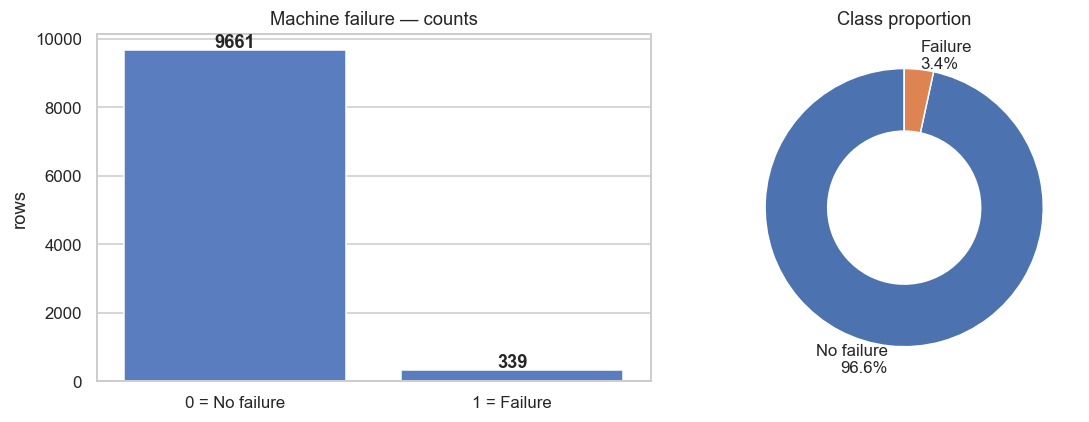

imbalance ratio  1 : 28


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = ai4i[TARGET].value_counts().sort_index()
sns.barplot(x=['0 = No failure', '1 = Failure'], y=counts.values, ax=ax[0])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 80, f'{v}', ha='center', fontweight='bold')
ax[0].set_title('Machine failure — counts'); ax[0].set_ylabel('rows')
pct = ai4i[TARGET].value_counts(normalize=True).sort_index() * 100
ax[1].pie(pct, labels=[f'No failure\n{pct[0]:.1f}%', f'Failure\n{pct[1]:.1f}%'],
          autopct='', colors=['#4c72b0', '#dd8452'], startangle=90,
          wedgeprops=dict(width=0.45))
ax[1].set_title('Class proportion')
plt.tight_layout(); plt.savefig(FIG / 'ai4i_target_balance.png', bbox_inches='tight'); plt.show()
print('imbalance ratio  1 : %.0f' % (counts[0]/counts[1]))

## A2. Feature distributions (histograms)
Shape of each sensor reading — is it normal, skewed, bimodal? Watch for skew.

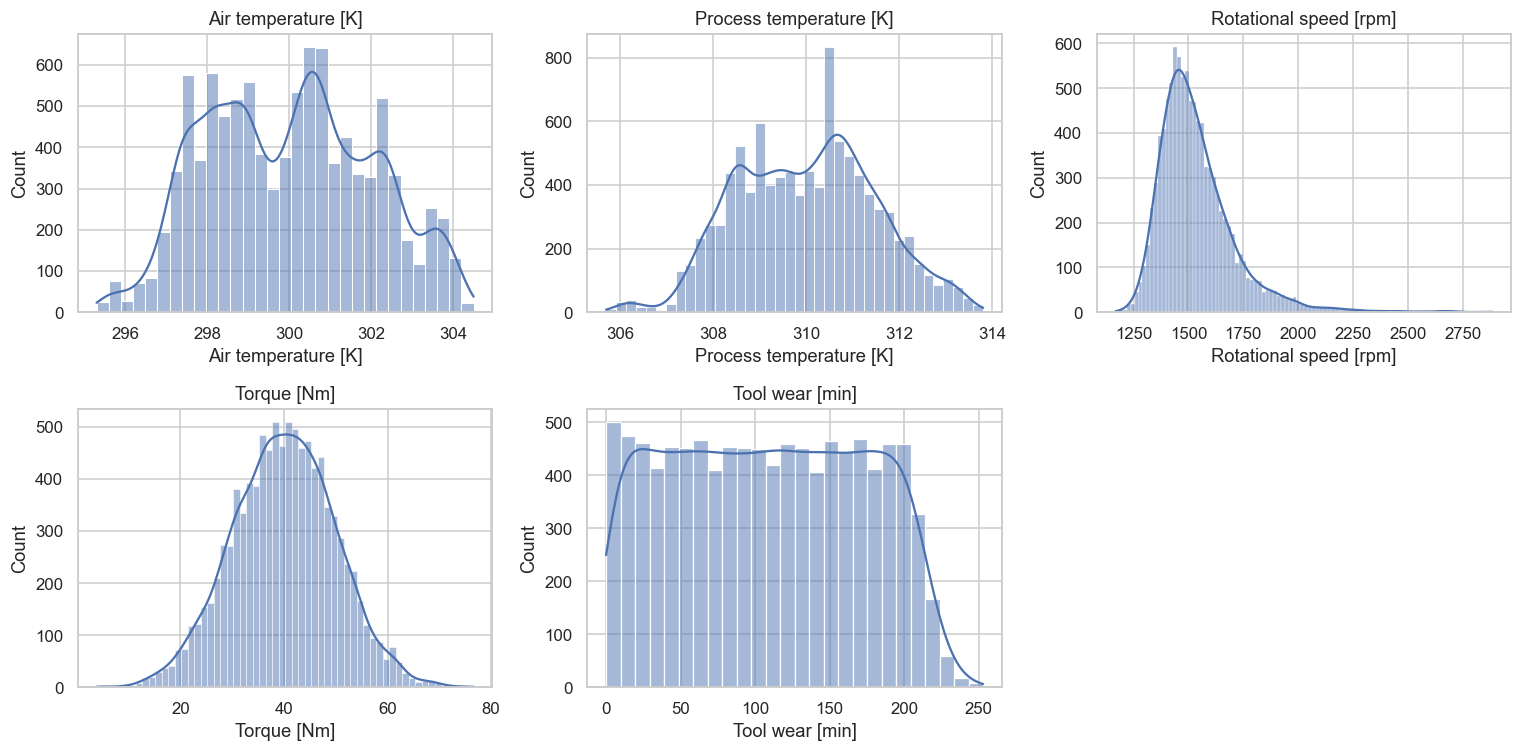

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), NUM):
    sns.histplot(ai4i[col], kde=True, ax=ax, color='#4c72b0')
    ax.set_title(col)
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.savefig(FIG / 'ai4i_distributions.png', bbox_inches='tight'); plt.show()

## A3. Outliers (boxplots)
Each dot beyond the whiskers is a potential outlier. `Rotational speed` and `Torque` typically show the most — often the very failure cases we care about, so we do **not** blindly delete them.

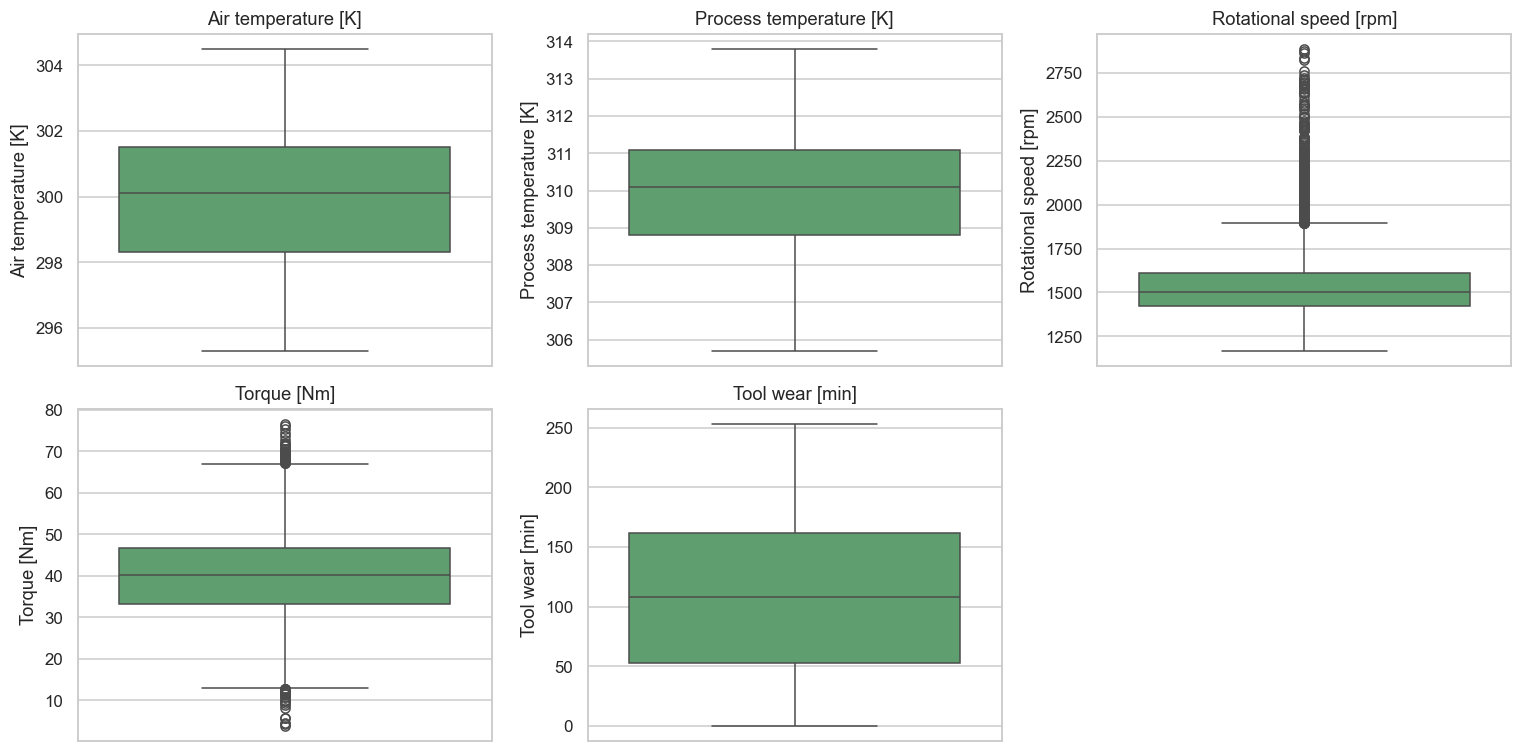

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), NUM):
    sns.boxplot(y=ai4i[col], ax=ax, color='#55a868')
    ax.set_title(col)
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.savefig(FIG / 'ai4i_outliers.png', bbox_inches='tight'); plt.show()

## A4. Correlation heatmap
How features move together, and how each relates to `Machine failure`. Strong feature-feature correlation = redundancy; feature-target correlation = predictive signal.

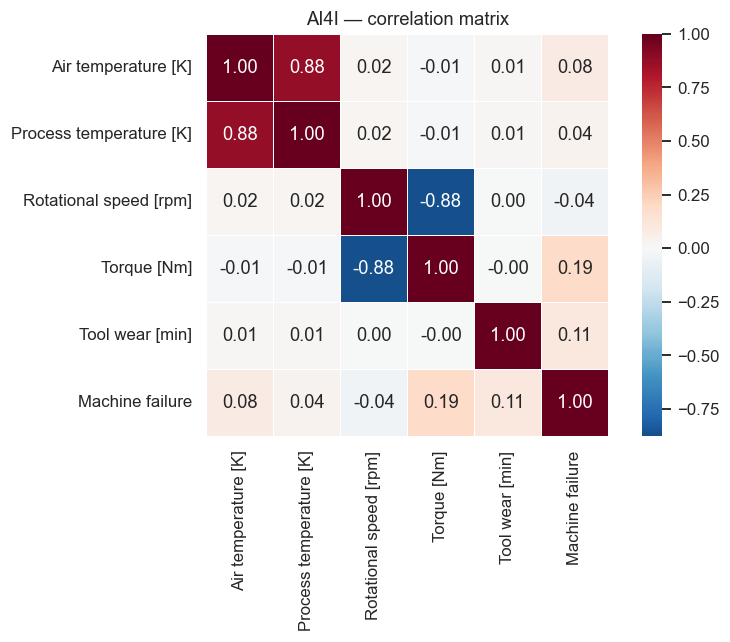

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = ai4i[NUM + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=.5, ax=ax)
ax.set_title('AI4I — correlation matrix')
plt.tight_layout(); plt.savefig(FIG / 'ai4i_correlation.png', bbox_inches='tight'); plt.show()

## A5. What separates a failure? (feature vs target)
**The most useful plot for modeling.** If a feature's distribution shifts between failure and no-failure, it carries predictive signal. Expect `Torque`, `Tool wear`, and `Rotational speed` to separate the classes.

C:\Users\CabbiePC\AppData\Local\Temp\ipykernel_21612\662786068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ai4i, x=TARGET, y=col, ax=ax, palette=['#4c72b0', '#dd8452'])
C:\Users\CabbiePC\AppData\Local\Temp\ipykernel_21612\662786068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ai4i, x=TARGET, y=col, ax=ax, palette=['#4c72b0', '#dd8452'])
C:\Users\CabbiePC\AppData\Local\Temp\ipykernel_21612\662786068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ai4i, x=TARGET, y=col, ax=ax, palette=['#4c72b0', '#dd8452'])
C

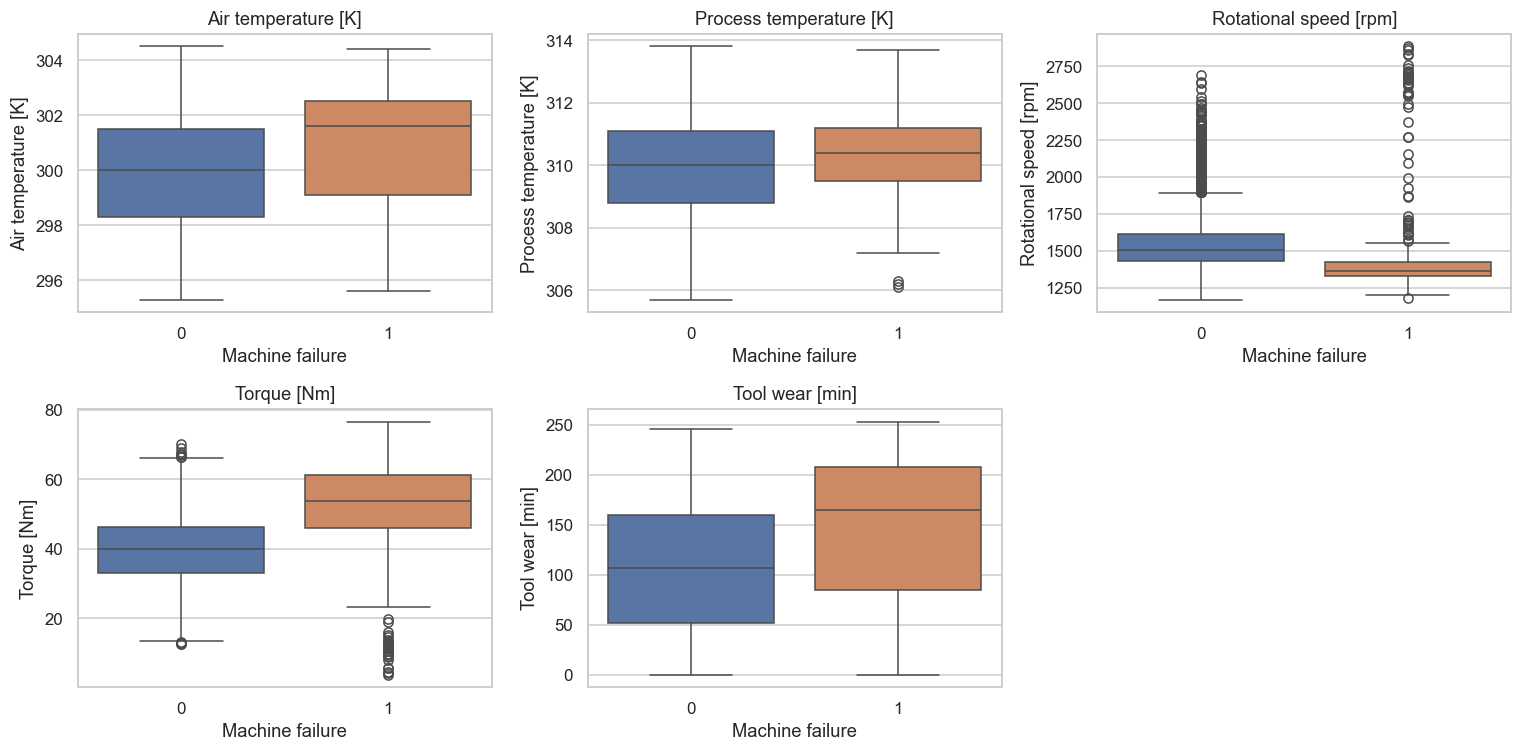

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), NUM):
    sns.boxplot(data=ai4i, x=TARGET, y=col, ax=ax, palette=['#4c72b0', '#dd8452'])
    ax.set_title(col); ax.set_xlabel('Machine failure')
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.savefig(FIG / 'ai4i_feature_vs_target.png', bbox_inches='tight'); plt.show()

## A6. Product quality `Type` and its failure rate

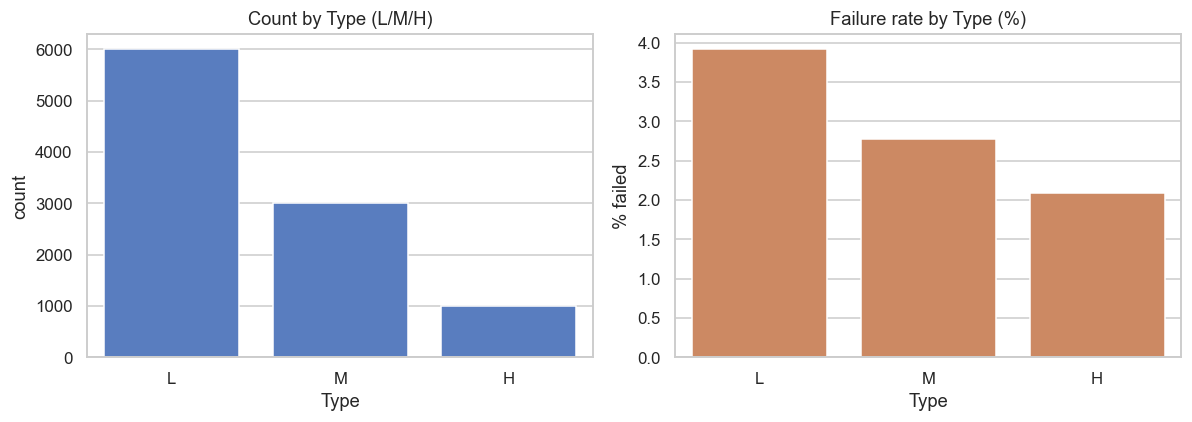

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=ai4i, x='Type', order=['L','M','H'], ax=ax[0])
ax[0].set_title('Count by Type (L/M/H)')
rate = ai4i.groupby('Type')[TARGET].mean().reindex(['L','M','H']) * 100
sns.barplot(x=rate.index, y=rate.values, ax=ax[1], color='#dd8452')
ax[1].set_title('Failure rate by Type (%)'); ax[1].set_ylabel('% failed')
plt.tight_layout(); plt.savefig(FIG / 'ai4i_type.png', bbox_inches='tight'); plt.show()

## A7. Which failure modes occur?
`Machine failure` = 1 when any of these fire. (We drop these for the basic model — they *define* the target, so using them as inputs would be leakage.)

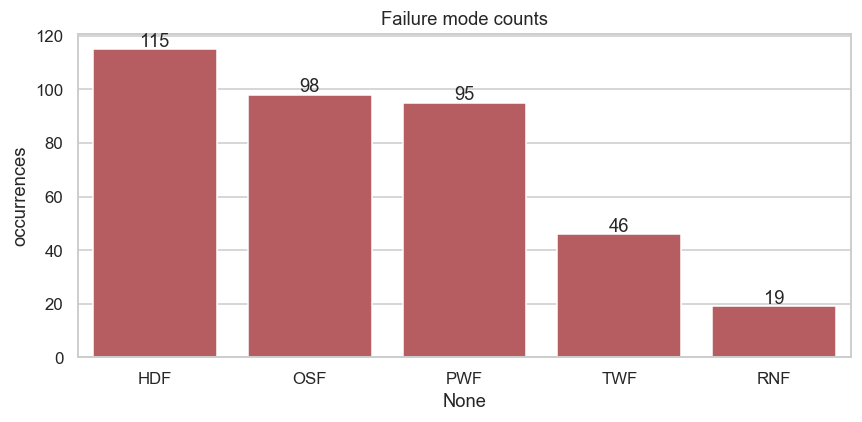

In [9]:
mode_counts = ai4i[MODES].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=mode_counts.index, y=mode_counts.values, ax=ax, color='#c44e52')
for i, v in enumerate(mode_counts.values):
    ax.text(i, v + 1, str(v), ha='center')
ax.set_title('Failure mode counts'); ax.set_ylabel('occurrences')
plt.tight_layout(); plt.savefig(FIG / 'ai4i_failure_modes.png', bbox_inches='tight'); plt.show()

---
# Part B — Fleet dataset (the scorecard)

In [10]:
fleet = pd.read_csv(DATA / 'maridive_fleet_synthetic.csv')
print('shape:', fleet.shape)
fleet.head()

shape: (49, 30)


,vessel_id,vessel_name,vessel_type,owner,year_built,vessel_age_years,engine_bhp,bollard_pull_t,crane_capacity_t,dp_class,...,unplanned_downtime_hours_12m,hse_incidents_12m,jobs_completed_12m,jobs_on_time_12m,on_time_completion_pct,avg_fuel_consumption_lpd,last_drydock_year,crew_id,crew_size,crew_avg_experience_years
0,MOS-001,Maridive 232,MPSV,MOS,2012.0,14.0,4800.0,NaN,80.0,DP II,...,32,2,9,8,88.9,11000.0,2022,CRW-001,26,12.0
1,MOS-002,Maridive 603,MPSV,Ocean Marine,2014.0,12.0,5400.0,NaN,100.0,DP II,...,33,2,11,8,72.7,18900.0,2023,CRW-002,22,5.3
2,MOS-003,Baraka 60,MPSV,MOS,2015.0,11.0,6000.0,NaN,40.0,DP II,...,38,1,10,7,70.0,22300.0,2023,CRW-003,23,11.7
3,MOS-004,Maridive 602,MPSV,MOS,2012.0,14.0,6000.0,NaN,80.0,DP II,...,93,1,12,9,75.0,19000.0,2022,CRW-004,23,8.3
4,MOS-005,Maridive ZEN 535,MPSV,MOP,2021.0,5.0,5150.0,NaN,40.0,DP II,...,50,1,10,9,90.0,16900.0,2023,CRW-005,18,6.4


## B1. Fleet composition

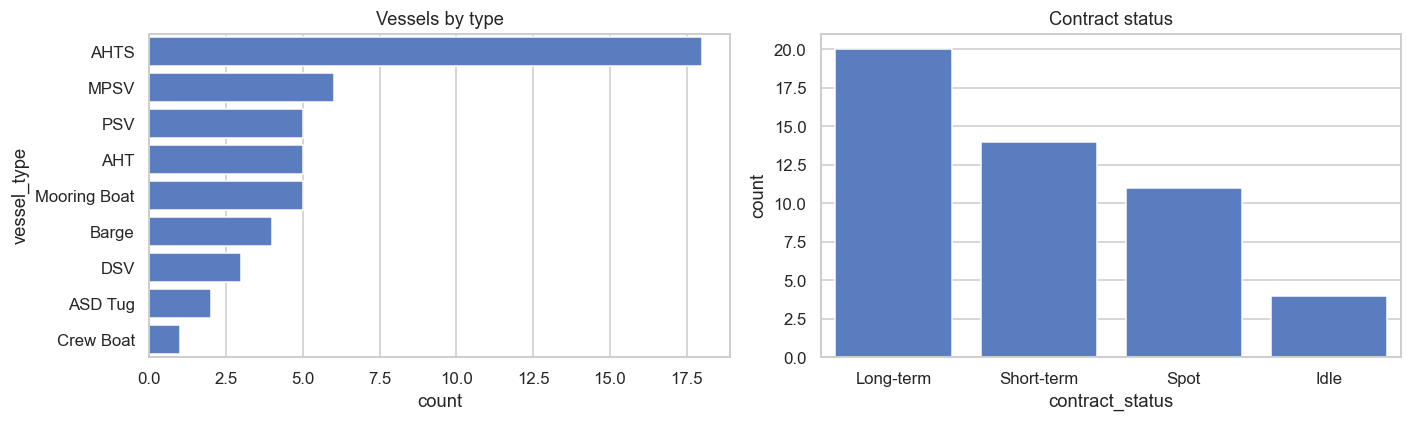

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=fleet, y='vessel_type',
              order=fleet['vessel_type'].value_counts().index, ax=ax[0])
ax[0].set_title('Vessels by type')
sns.countplot(data=fleet, x='contract_status',
              order=fleet['contract_status'].value_counts().index, ax=ax[1])
ax[1].set_title('Contract status')
plt.tight_layout(); plt.savefig(FIG / 'fleet_composition.png', bbox_inches='tight'); plt.show()

## B2. Utilization — distribution and by contract status
Utilization is the #1 KPI. Idle vessels should sit far left; long-term contracts high.

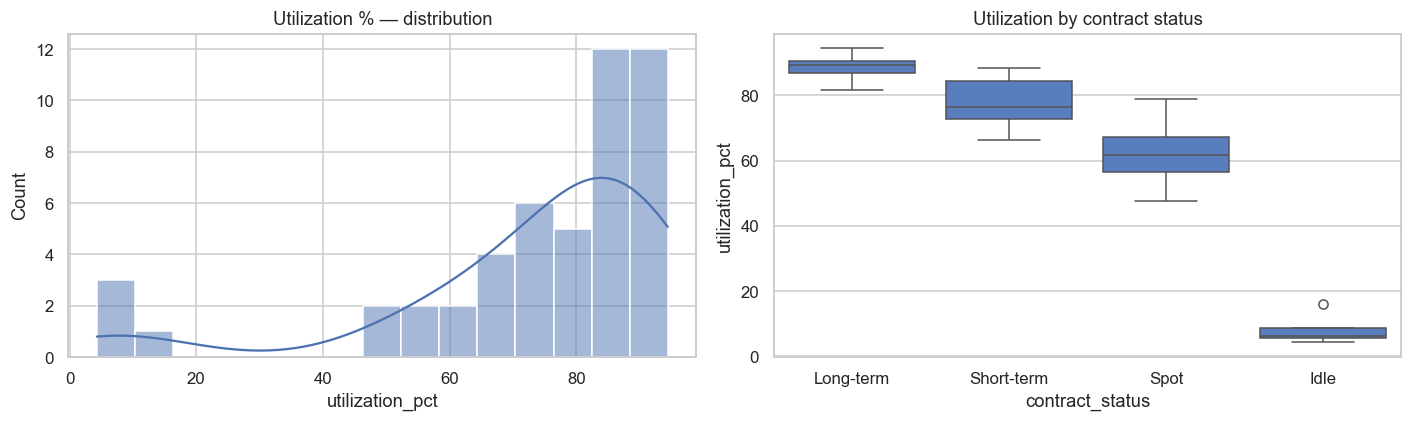

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(fleet['utilization_pct'], bins=15, kde=True, ax=ax[0], color='#4c72b0')
ax[0].set_title('Utilization % — distribution')
sns.boxplot(data=fleet, x='contract_status', y='utilization_pct',
            order=['Long-term','Short-term','Spot','Idle'], ax=ax[1])
ax[1].set_title('Utilization by contract status')
plt.tight_layout(); plt.savefig(FIG / 'fleet_utilization.png', bbox_inches='tight'); plt.show()

## B3. Correlation among operational metrics
These are the ingredients of the performance score (M4). Do they relate sensibly? (e.g. more downtime → lower on-time completion).

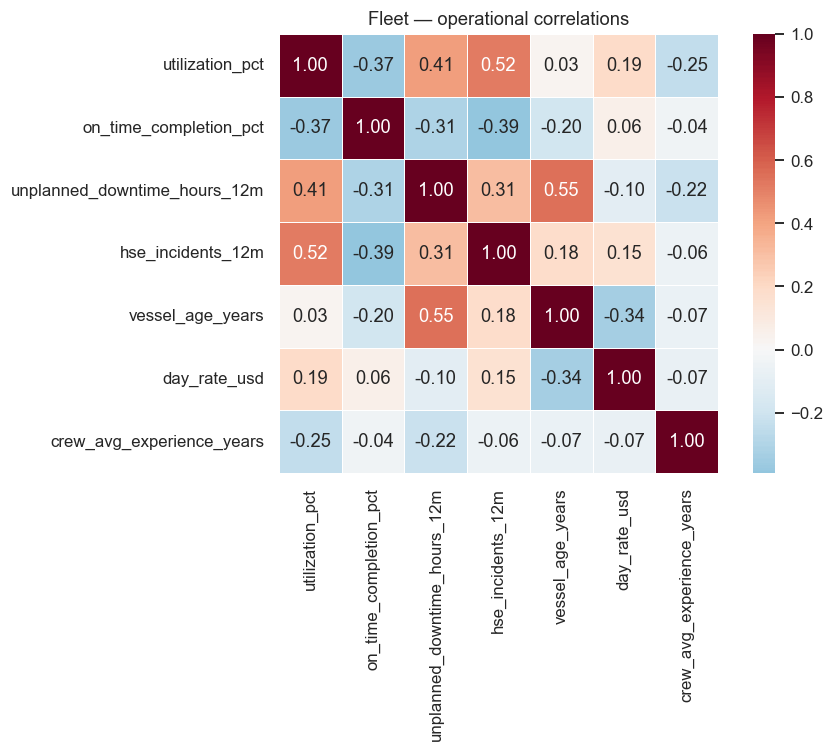

In [13]:
ops = ['utilization_pct', 'on_time_completion_pct', 'unplanned_downtime_hours_12m',
       'hse_incidents_12m', 'vessel_age_years', 'day_rate_usd',
       'crew_avg_experience_years']
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(fleet[ops].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=.5, ax=ax)
ax.set_title('Fleet — operational correlations')
plt.tight_layout(); plt.savefig(FIG / 'fleet_correlation.png', bbox_inches='tight'); plt.show()

## B4. Outliers in key operational metrics

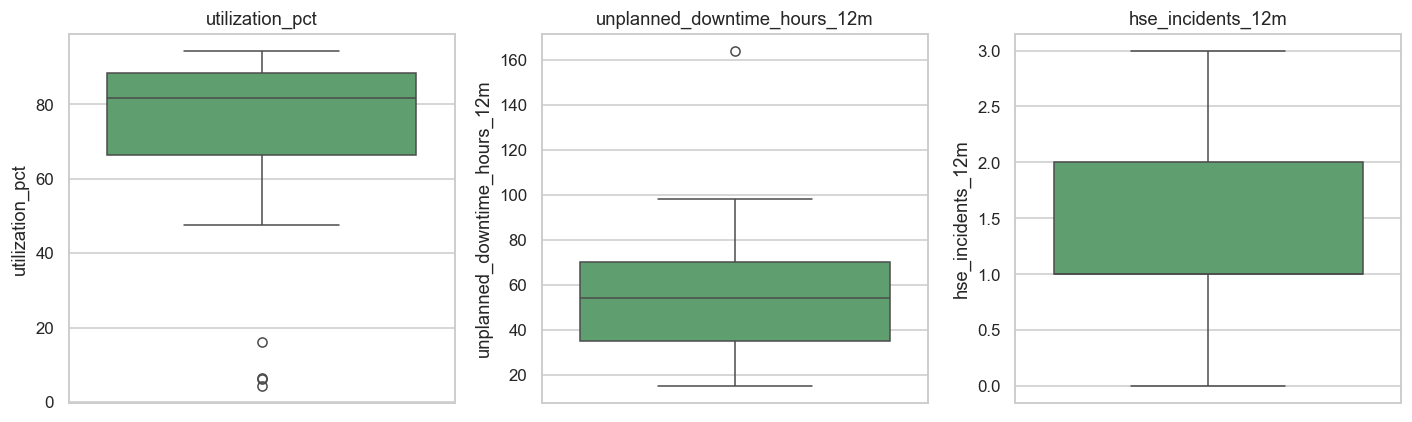

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['utilization_pct', 'unplanned_downtime_hours_12m', 'hse_incidents_12m']):
    sns.boxplot(y=fleet[col], ax=ax, color='#55a868'); ax.set_title(col)
plt.tight_layout(); plt.savefig(FIG / 'fleet_outliers.png', bbox_inches='tight'); plt.show()

---
## Key takeaways
**AI4I (ML):**
- Target is severely imbalanced (~3.4% failures) → use **precision / recall / PR-AUC**, not accuracy; consider class weights / resampling in M5.
- `Torque`, `Tool wear`, `Rotational speed` separate failures best → strong features.
- Drop `UDI`, `Product ID` (identifiers) and `TWF/HDF/PWF/OSF/RNF` (leakage) for the basic model.

**Fleet (scorecard):**
- Utilization cleanly tracks contract status (Idle vessels low) → the score will be intuitive.
- Missing values are structural (barges have no engine/fuel) → handle in M2 cleaning, don't 'fill' blindly.